In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# 1. Učitavanje i priprema indeksa
df = pd.read_csv("data/sve.csv", index_col="Date", parse_dates=True)
df = df.sort_index()

# 2. Sužavanje na isti period i resamplovanje na dnevni nivo (petkom)
df = df.loc["1999-01-01":"2026-06-01"]
#df = df.resample("W-FRI").last().ffill()

# 3. Definisanje vremenske serije za ARIMA model
ts = df['EURUSD'].dropna()

print(f"Period nakon resamplovanja: {ts.index.min().strftime('%Y-%m-%d')} do {ts.index.max().strftime('%Y-%m-%d')}")
print(f"Broj dnevnih opservacija: {len(ts)}")

display(df.head())

Period nakon resamplovanja: 1999-01-01 do 2026-06-01
Broj dnevnih opservacija: 10014


,CPI,HICP,GER2Y,GER10Y,USA2Y,USA10Y,EURUSD
Date,,,,,,,
1999-01-01,164.7,57.07,3.071,3.863,4.575,4.677,1.1680
1999-01-02,164.7,57.07,3.071,3.863,4.575,4.677,1.1680
1999-01-03,164.7,57.07,3.071,3.863,4.575,4.677,1.1680
1999-01-04,164.7,57.07,3.071,3.748,4.575,4.677,1.1812
1999-01-05,164.7,57.07,3.089,3.791,4.641,4.745,1.1755


In [3]:
train_size = int(len(ts) * 0.8)
train, test = ts[0:train_size], ts[train_size:]

print(f"Ukupno uzoraka: {len(ts)}")
print(f"Trening skup: {len(train)} uzoraka")
print(f"Test skup: {len(test)} uzoraka")

Ukupno uzoraka: 10014
Trening skup: 8011 uzoraka
Test skup: 2003 uzoraka


In [4]:
naive_predictions = test.shift(1)
naive_predictions.iloc[0] = train.iloc[-1]

naive_rmse = np.sqrt(mean_squared_error(test, naive_predictions))
naive_mae = mean_absolute_error(test, naive_predictions)

print("NAIVNI MODEL METRIKE :")
print(f"MAE:  {naive_mae:.5f}")
print(f"RMSE: {naive_rmse:.5f}")

NAIVNI MODEL METRIKE :
MAE:  0.00304
RMSE: 0.00451


ADF p-vrednost (Originalni podaci): 0.4622
Podaci nisu stacionarni -> Postavljamo d = 1


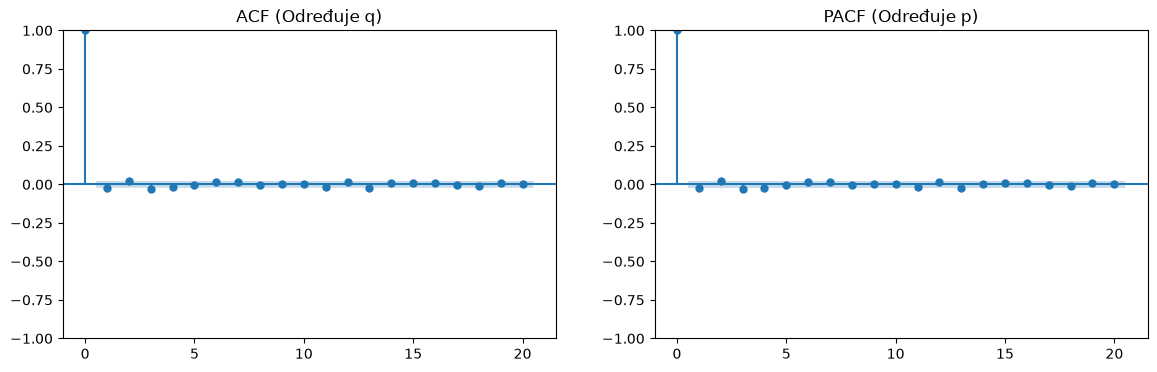

c:\Users\Aca\Desktop\Petnica\Mentorski rad\Currency-Ecxhange-Rate-Predictor\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Aca\Desktop\Petnica\Mentorski rad\Currency-Ecxhange-Rate-Predictor\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Aca\Desktop\Petnica\Mentorski rad\Currency-Ecxhange-Rate-Predictor\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Aca\Desktop\Petnica\Mentorski rad\Currency-Ecxhange-Rate-Predictor\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 


Optimalni ARIMA red prema Box-Jenkins metodologiji: ARIMA(0, 1, 0)


c:\Users\Aca\Desktop\Petnica\Mentorski rad\Currency-Ecxhange-Rate-Predictor\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Aca\Desktop\Petnica\Mentorski rad\Currency-Ecxhange-Rate-Predictor\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Aca\Desktop\Petnica\Mentorski rad\Currency-Ecxhange-Rate-Predictor\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Ljung-Box test p-vrednost reziduala: 0.9862

[STATUS: YES] Reziduali JESU beli šum (nema autokorelacije).
-> Model je adekvatan. Možete preći na korak 4: Forecast (Predikcija).


In [5]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Određivanje d pomoću ADF testa
adf_result = adfuller(train)
print(f"ADF p-vrednost (Originalni podaci): {adf_result[1]:.4f}")

if adf_result[1] > 0.05:
    d = 1
    print("Podaci nisu stacionarni -> Postavljamo d = 1")
else:
    d = 0
    print("Podaci su stacionarni -> Postavljamo d = 0")

# Diferencirani podaci za analizu grafika
diff_train = train.diff().dropna() if d == 1 else train

# 2. Prikaz ACF i PACF za procenu p i q
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(diff_train, lags=20, ax=axes[0], title='ACF (Određuje q)')
plot_pacf(diff_train, lags=20, ax=axes[1], title='PACF (Određuje p)')
plt.show()

# 3. Minimizacija BIC / AIC kriterijuma
best_bic = float('inf')
best_order = None

for p in range(0, 6):
    for q in range(0, 6):
        try:
            model = ARIMA(train, order=(p, d, q)).fit()
            if model.bic < best_bic:
                best_bic = model.bic
                best_order = (p, d, q)
        except Exception:
            continue

print(f"\nOptimalni ARIMA red prema Box-Jenkins metodologiji: ARIMA{best_order}")

# 4. Provera reziduala odabranog modela (Ljung-Box test) i dijagnostika sa dijagrama
final_model = ARIMA(train, order=best_order).fit()
lb_test = acorr_ljungbox(final_model.resid, lags=[10], return_df=True)
lb_pvalue = lb_test['lb_pvalue'].values[0]

print(f"Ljung-Box test p-vrednost reziduala: {lb_pvalue:.4f}")

# Provera logike na osnovu dijagrama
if lb_pvalue > 0.05:
    print("\n[STATUS: YES] Reziduali JESU beli šum (nema autokorelacije).")
    print("-> Model je adekvatan. Možete preći na korak 4: Forecast (Predikcija).")
else:
    print("\n[STATUS: NO] Reziduali NISU beli šum (ostala je autokorelacija/sezonalnost).")
    print("-> Preporuka sa dijagrama: Prilagoditi (p, d, q) parametre ili pokušati SARIMA model.")

In [6]:
import warnings

warnings.simplefilter('ignore')

p, d, q = best_order

# Treniramo ARIMA model jednom na celom trening skupu
model = ARIMA(train, order=(p, d, q))
model_fit = model.fit()

# Koristimo append() da ažuriramo stanje modela sa test podacima bez ponovnog sporog treniranja
# Ovo pravi refit sa fiksiranim parametrima što radi drastično brže!
updated_model = model_fit.append(test, refit=False)

# Dobijamo predikcije za test period (one-step ahead)
arima_predictions = updated_model.predict(start=test.index[0], end=test.index[-1])

print("Predikcija uspešno i brzo završena!")

Predikcija uspešno i brzo završena!


In [7]:
from sklearn.metrics import r2_score

print("Predikcija uspešno i brzo završena!")

# ARIMA metrike
arima_rmse = np.sqrt(mean_squared_error(test, arima_predictions))
arima_mae = mean_absolute_error(test, arima_predictions)
arima_mape = mean_absolute_percentage_error(test, arima_predictions) * 100

# R²
arima_r2 = r2_score(test, arima_predictions)

# Adjusted R²
n = len(test)
k = p + q

if n - k - 1 > 0:
    arima_adjusted_r2 = 1 - (1 - arima_r2) * (n - 1) / (n - k - 1)
else:
    arima_adjusted_r2 = np.nan

print(f"--- ARIMA ({p},{d},{q}) MODEL METRIKE ---")
print(f"MAE:           {arima_mae:.5f}")
print(f"RMSE:          {arima_rmse:.5f}")
print(f"MAPE:          {arima_mape:.2f}%")
print(f"R²:            {arima_r2:.5f}")
print(f"Adjusted R²:   {arima_adjusted_r2:.5f}")


Predikcija uspešno i brzo završena!
--- ARIMA (0,1,0) MODEL METRIKE ---
MAE:           0.00304
RMSE:          0.00451
MAPE:          0.28%
R²:            0.99412
Adjusted R²:   0.99412


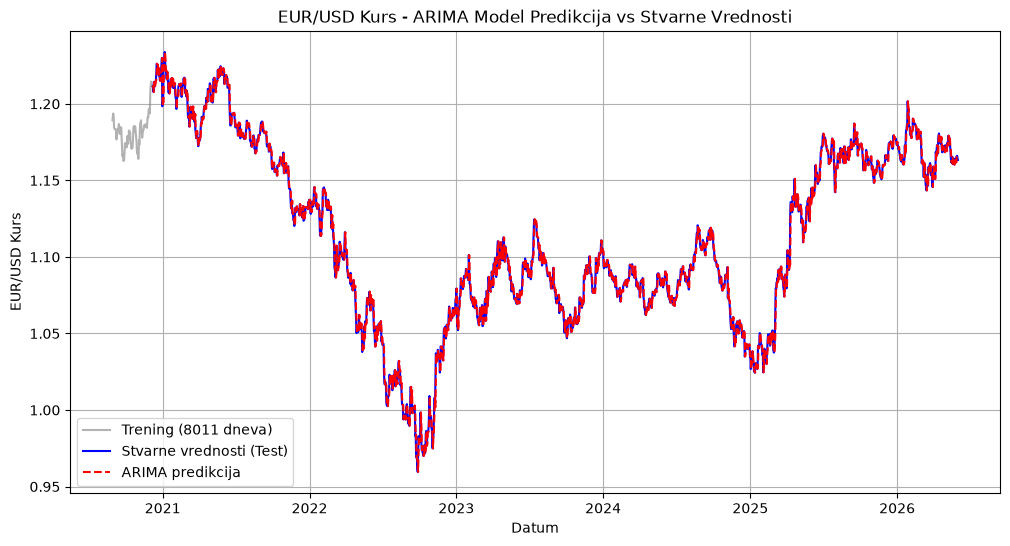

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(train.index[-100:], train.values[-100:], label=f'Trening ({len(train)} dneva)', color='gray', alpha=0.6)
plt.plot(test.index, test.values, label='Stvarne vrednosti (Test)', color='blue')
plt.plot(test.index, arima_predictions, label='ARIMA predikcija', color='red', linestyle='--')

plt.title('EUR/USD Kurs - ARIMA Model Predikcija vs Stvarne Vrednosti')
plt.xlabel('Datum')
plt.ylabel('EUR/USD Kurs')
plt.legend()
plt.grid(True)
plt.show()

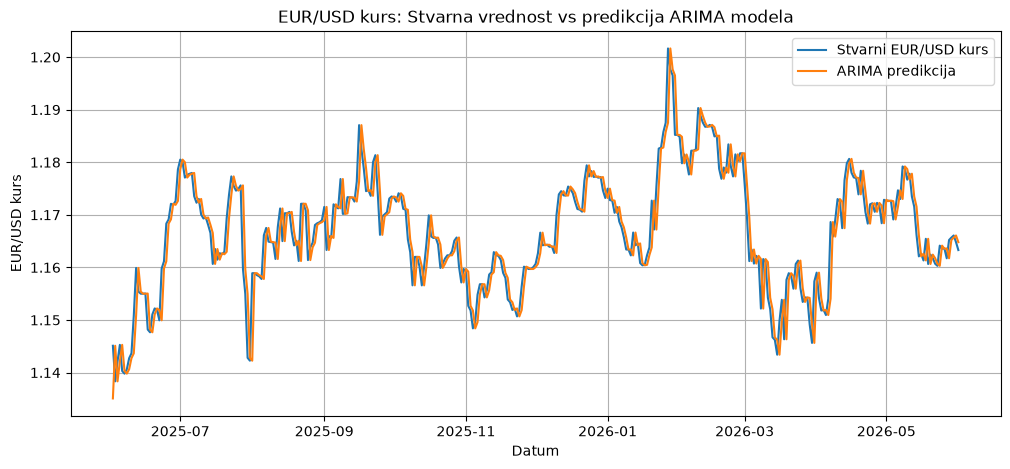

In [9]:
presek = -365

test_dates = test.index

plt.figure(figsize=(12, 5))

plt.plot(
    test_dates[presek:],
    test.iloc[presek:],
    label="Stvarni EUR/USD kurs"
)

plt.plot(
    test_dates[presek:],
    arima_predictions.iloc[presek:],
    label="ARIMA predikcija"
)

plt.title(
    "EUR/USD kurs: Stvarna vrednost vs predikcija ARIMA modela"
)
plt.xlabel("Datum")
plt.ylabel("EUR/USD kurs")

plt.legend()
plt.grid()

plt.show()

## Ignoriši

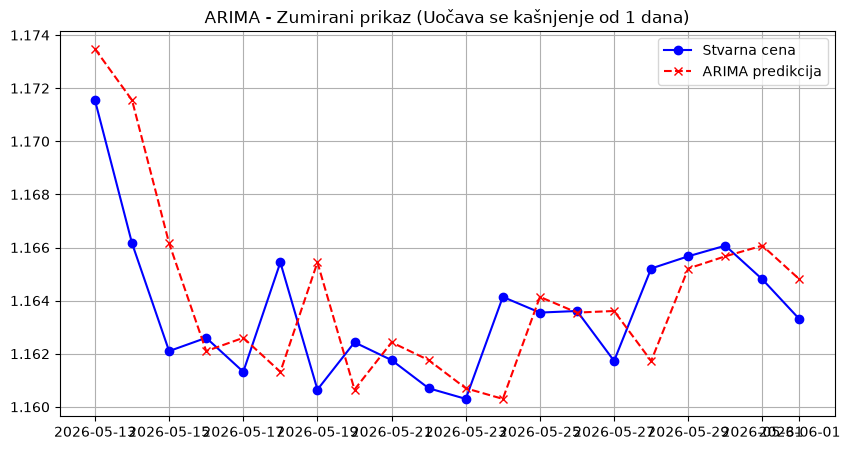

In [10]:
# Zumirani prikaz na poslednjih 20 dana
plt.figure(figsize=(10, 5))
plt.plot(test.index[-20:], test.values[-20:], label='Stvarna cena', color='blue', marker='o')
plt.plot(test.index[-20:], arima_predictions.values[-20:], label='ARIMA predikcija', color='red', linestyle='--', marker='x')
plt.title('ARIMA - Zumirani prikaz (Uočava se kašnjenje od 1 dana)')
plt.legend()
plt.grid(True)
plt.show()

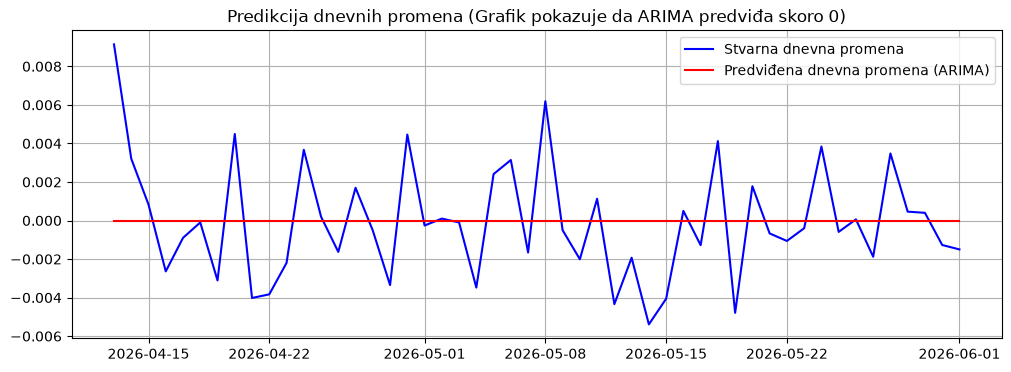

In [11]:
# Stvarna dnevna promena cene vs Predvidjena dnevna promena cene
actual_diff = test.diff().dropna()
predicted_diff = (arima_predictions - test.shift(1)).dropna()

plt.figure(figsize=(12, 4))
plt.plot(actual_diff.index[-50:], actual_diff.values[-50:], label='Stvarna dnevna promena', color='blue')
plt.plot(predicted_diff.index[-50:], predicted_diff.values[-50:], label='Predviđena dnevna promena (ARIMA)', color='red')
plt.title('Predikcija dnevnih promena (Grafik pokazuje da ARIMA predviđa skoro 0)')
plt.legend()
plt.grid(True)
plt.show()